# **TALASH — Talent Acquisition & Learning Automation for Smart Hiring**
### **Course: CS417 — Large Language Models &nbsp;|&nbsp; Milestone 2**

---

## **System Architecture**

```
INPUT          →  PDF CVs (single or multi-candidate per file)
PREPROCESSING  →  Text extraction · Cleaning · Candidate boundary detection
EXTRACTION     →  Personal · Education · Experience · Publications · Awards · Patents · References · Skills
LLM ANALYSIS   →  Real OpenAI API — structured JSON prompt → research quality, summaries, skill alignment, gap justification
RANKING        →  Weighted score (Education 35% · Experience 35% · Research 20% · Completeness 10%)
OUTPUT         →  Excel (16 sheets) · JSON · CSV · Draft emails · Dashboard chart
```

In [1]:
#Install libraries
!pip install pypdf pandas openpyxl matplotlib plotly ipywidgets numpy openai -q
print('All libraries installed successfully.')

All libraries installed successfully.


In [2]:
# Imports & Configuration
import os, re, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pypdf import PdfReader
from datetime import datetime

warnings.filterwarnings('ignore')

# Folder paths
CV_FOLDER        = 'cvs'
OUTPUT_FOLDER    = 'outputs'
SPLIT_TXT_FOLDER = 'outputs/split_candidates'
OUTPUT_EXCEL     = 'outputs/talash_m2_output.xlsx'
OUTPUT_JSON      = 'outputs/talash_m2_output.json'
OUTPUT_CSV       = 'outputs/talash_m2_personal.csv'

# Scoring weights (must sum to 1.0)
WEIGHT_EDU  = 0.35
WEIGHT_EXP  = 0.35
WEIGHT_RES  = 0.20
WEIGHT_COMP = 0.10

# LLM Configuration

USE_LLM  = True
API_KEY  = ''

for d in [CV_FOLDER, OUTPUT_FOLDER, SPLIT_TXT_FOLDER]:
    os.makedirs(d, exist_ok=True)

print('  TALASH — Milestone 2')
print(f'  CV Folder    : {CV_FOLDER}/')
print(f'  Output Folder: {OUTPUT_FOLDER}/')
print(f'  Run Time     : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  Weights      : Edu={WEIGHT_EDU*100:.0f}%  Exp={WEIGHT_EXP*100:.0f}%  Res={WEIGHT_RES*100:.0f}%  Complete={WEIGHT_COMP*100:.0f}%')
print(f'  LLM Mode     : {"REAL API (Gemini)" if USE_LLM and API_KEY else "Rule-based (set USE_LLM=True to enable)"}')
print('Configuration loaded.')

  TALASH — Milestone 2
  CV Folder    : cvs/
  Output Folder: outputs/
  Run Time     : 2026-04-27 14:56:14
  Weights      : Edu=35%  Exp=35%  Res=20%  Complete=10%
  LLM Mode     : REAL API (Gemini)
Configuration loaded.


## **Preprocessing Module**


In [3]:
import shutil

source_file = '/content/Handler (8).pdf'
destination_folder = CV_FOLDER

if os.path.exists(source_file):
    shutil.move(source_file, os.path.join(destination_folder, os.path.basename(source_file)))
    print(f'Moved {os.path.basename(source_file)} to {destination_folder}/')
else:
    print(f'File {source_file} not found. Assuming it\'s already moved or not present.')

File /content/Handler (8).pdf not found. Assuming it's already moved or not present.


In [4]:
# Preprocessing Module

_GLOBAL_ID = 0

def get_next_id():
    global _GLOBAL_ID
    _GLOBAL_ID += 1
    return _GLOBAL_ID

def reset_id_counter():
    global _GLOBAL_ID
    _GLOBAL_ID = 0


def read_pdf_pages(path):
    """Read every page of a PDF; one bad page never crashes the run."""
    pages, errors = [], []
    try:
        reader = PdfReader(path)
        for pg_num, page in enumerate(reader.pages):
            try:
                text = page.extract_text()
                pages.append(text.strip() if text else '')
            except Exception as e:
                errors.append(f'Page {pg_num}: {e}')
                pages.append('')
    except Exception as e:
        errors.append(f'Cannot open PDF: {e}')
    return pages, errors


def clean_text(text):
    """Strip control characters and collapse excess spaces."""
    if not text:
        return ''
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', ' ', text)
    text = re.sub(r' {3,}', '  ', text)
    return text.strip()


def is_candidate_start(text):

    head = text[:600]

    # Signal 1 — Professional Qualification header
    if re.match(r'\s*Professional\s+Qualification', head, re.IGNORECASE):
        return True

    # Signal 2 — Name line + Father's / Guardian within 300 chars
    m = re.search(
        r'(?:^|\n)\s*Name\s+'
        r'(?!of\s+(?:Degree|Post|Contact|Qualification|Author|Organization|CO-Author))'
        r'([A-Z][A-Za-z]{1,})',
        head, re.MULTILINE
    )
    if m:
        # Reject reference-table column headers
        matched_line = head[m.start(): m.start() + 120]
        if re.search(r'(Contact|Reference|Designation)', matched_line, re.IGNORECASE):
            return False
        fathers = re.search(r"Father's", head, re.IGNORECASE)
        if fathers and (fathers.start() - m.start()) < 300:
            return True

    return False


def group_candidates(pages):
    """Group consecutive pages belonging to the same candidate."""
    candidates, current = [], []
    for page in pages:
        cleaned = clean_text(page)
        if not cleaned:
            continue
        if is_candidate_start(cleaned):
            if current:
                candidates.append('\n'.join(current))
            current = [cleaned]
        else:
            current.append(cleaned)
    if current:
        candidates.append('\n'.join(current))
    return candidates


def detect_pdf_type(candidates):
    n = len(candidates)
    if n > 1:   return 'MULTI',  f'{n} candidate boundaries detected'
    elif n == 1: return 'SINGLE', 'Single CV'
    else:        return 'SINGLE', 'No boundaries found — treating as one'


def save_candidate_text(block, source_name, seg_no):
    safe = re.sub(r'[^\w\-]', '_', source_name.replace('.pdf', ''))
    path = f'{SPLIT_TXT_FOLDER}/{safe}_cand_{seg_no:02d}.txt'
    try:
        with open(path, 'w', encoding='utf-8') as f:
            f.write(block)
    except Exception:
        pass


## **Extraction Functions — Module A**

In [5]:
# Extraction Functions

_CTRL_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f]')   # pre-compiled for clean_for_excel

def get_field(pattern, text, default='N/A', group=1):
    try:
        m = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
        return m.group(group).strip() if m else default
    except Exception:
        return default


def clean_degree_name(raw):
    cleaned = re.sub(r'([a-z])([A-Z])', r'\1 \2', raw)
    cleaned = re.sub(r'([A-Z]{2,})([A-Z][a-z])', r'\1 \2', cleaned)
    cleaned = re.sub(r'\bPh\s+D\b', 'PhD', cleaned, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', cleaned).strip()


def merge_edu_lines(raw_section):
    lines = raw_section.split('\n')
    merged, buffer = [], ''
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if re.match(r'^(GPA|Passing|Year|Board|Specialization|Grade|%age)', line, re.IGNORECASE):
            continue
        if re.search(r'\b(19|20)\d{2}\b', line):
            buffer = (buffer + ' ' + line).strip() if buffer else line
            merged.append(buffer)
            buffer = ''
        else:
            buffer = (buffer + ' ' + line).strip() if buffer else line
    if buffer:
        merged.append(buffer)
    return merged


DEGREE_KEYWORDS = [
    'phd','ph.d','doctor','mphil','m.phil','ms ','msc','m.sc','master',
    'mba','meng','m.engg','m.e.','postdoc','bs ','bsc','b.sc','bachelor',
    'be ','b.e','b.eng','beng','hssc','fsc','f.sc','intermediate',
    'a-level','a level','ssc','s.sc','matric','o-level','o level',
    'secondary school','higher secondary','primary','diploma','d.a.e','dae',
    'certificate','engineering','engg','science','pre-eng','pre engineering'
]

def has_degree_keyword(line):
    t = line.lower()
    return any(k in t for k in DEGREE_KEYWORDS)


# Personal
def extract_personal(text, gid, source, seg_no, total_in_pdf):
    name = 'N/A'
    try:
        m = re.search(
            r'(?:^|\n)\s*Name\s+'
            r'(?!of\s+(?:Degree|Post|Contact|Qualification|Author|Organization|CO))'
            r'(.+?)(?:Father\'s|/Guardian)',
            text, re.IGNORECASE | re.DOTALL
        )
        if m:
            parts = []
            for line in m.group(1).split('\n'):
                line = line.strip()
                if not line: continue
                if re.search(r'(Father|Guardian|Date|Spouse|Salary|Marital|Unit|Corps|SOD|SOS)', line, re.IGNORECASE):
                    break
                parts.append(line)
            name = ' '.join(parts).strip()
            name = re.sub(r'\s*(Father|Guardian|Date|Spouse|Salary|Unit).*', '', name, flags=re.IGNORECASE).strip()
    except Exception:
        pass

    dob = 'N/A'
    try:
        dob_m = re.search(r'Date/Place of\s*(?:\n\s*)?Birth:\s*([\d\-A-Za-z /\n]+)', text)
        if dob_m:
            raw = dob_m.group(1).replace('\n', ' ').strip()
            dob = raw.split('/')[0].strip().rstrip('/').strip()
            if not re.search(r'\d{4}', dob): dob = 'N/A'
    except Exception:
        pass

    employment = 'N/A'
    try:
        for pat in [
            r'Present\s*\nEmployment:\s*\n?(.*?)(?:\nServing|\nExpected)',
            r'Present\s+Employment:\s*(.*?)(?:\nServing|\nExpected|$)',
        ]:
            emp_m = re.search(pat, text, re.DOTALL | re.IGNORECASE)
            if emp_m:
                employment = emp_m.group(1).replace('\n', ' ').strip()
                break
    except Exception:
        pass

    email_m = re.search(r'([\w\.\+\-]+@[\w\.\-]+\.\w{2,})', text)
    email   = email_m.group(1) if email_m else 'N/A'

    phone = 'N/A'
    for pat in [
        r'(?:Phone|Mobile|Cell)[:\s]+(\+?[\d\s\-\.]{8,})',
        r'(\+92[\s\-]?\d{3}[\s\-]?\d{7})',
        r'(0[0-9]{10})',
    ]:
        pm = re.search(pat, text, re.IGNORECASE)
        if pm:
            phone = pm.group(1).strip()
            break

    return {
        'candidate_id':            gid,
        'Name':                    name if name else 'N/A',
        'Date of Birth':           dob,
        'Marital Status':          get_field(r'Marital Status[:\s]+(\w[\w\s\-]+?)(?:\n|Unit|SOD)', text),
        'Current Salary':          get_field(r'Current Salary[:\s]+(\d[\d,\.]+)', text),
        'Expected Salary':         get_field(r'Expected Salary[:\s]+(\d[\d,\.]+)', text),
        'Present Employment':      employment,
        'Applying For':            get_field(r'Candidate for the Post of\s+(.+?)(?:\s*\(Apply|\n)', text),
        'Apply Date':              get_field(r'Apply Date:\s*([\d\-A-Za-z]+)', text),
        'Email':                   email,
        'Phone':                   phone,
        'Source File':             source,
        'candidate_segment_no':    seg_no,
        'total_candidates_in_pdf': total_in_pdf,
        'extracted_from_multi_cv': 'Yes' if total_in_pdf > 1 else 'No',
    }


# Education
def extract_education(text, cid):
    rows = []
    try:
        edu_m = re.search(
            r'Education\s*\nName of Degree\s+Specialization.+?\n(.*?)'
            r'(?:Candidate for the Post|Civil Experience|Professional Qualification\nCivil)',
            text, re.DOTALL | re.IGNORECASE
        )
        if not edu_m: return rows
        for line in merge_edu_lines(edu_m.group(1)):
            line = line.strip()
            if not line or len(line) < 5: continue
            if re.match(r'(Name of|Board/Uni|Passing|Speciali|Grade|^Degree)', line, re.IGNORECASE): continue
            year_m = re.search(r'\b(19|20)(\d{2})\b', line)
            if not year_m: continue
            if not has_degree_keyword(line): continue
            grade_m = re.search(r'(\d+\.\d+)%?\s*(?=(?:19|20)\d{2})', line)
            if not grade_m:
                grade_m = re.search(r'\b(\d{2,3}(?:\.\d+)?%?)\s+(?=(?:19|20)\d{2})', line)
            grade = grade_m.group(1).replace('%', '') if grade_m else 'N/A'
            raw_degree = line[:grade_m.start()].strip() if grade_m else line[:year_m.start()].strip()
            rows.append({'candidate_id': cid, 'Degree/Details': clean_degree_name(raw_degree)[:120],
                         'Year': year_m.group(0), 'Grade/CGPA': grade})
    except Exception as e:
        rows.append({'candidate_id': cid, 'Degree/Details': f'[Error: {e}]', 'Year': 'N/A', 'Grade/CGPA': 'N/A'})
    return rows


# Professional Qualifications
def extract_prof_qual(text, cid):
    rows = []
    try:
        pq_m = re.search(
            r'Name of Qualification[:\s]*Passing Year[:\s]*Institution Name[:\s]*\n(.*?)'
            r'(?:Name of Post|Civil Experience\s*\nName|$)',
            text, re.DOTALL | re.IGNORECASE
        )
        if not pq_m: return rows
        for line in pq_m.group(1).split('\n'):
            line = line.strip()
            if not line or len(line) < 5: continue
            year_m = re.search(r'\b(19|20)\d{2}\b', line)
            rows.append({'candidate_id': cid, 'Qualification': line[:150],
                         'Year': year_m.group(0) if year_m else 'N/A'})
    except Exception:
        pass
    return rows


# Experience
def extract_experience(text, cid):
    rows = []
    try:
        exp_m = re.search(
            r'Name\s+of\s+Post\s+Organization\s+Location\s+Duration\s+of\s+Employment\s*\n(.*?)'
            r'(?:Paper\s+Title|Research\s*\n?\s*Publications|Awards|References|Patents|$)',
            text, re.DOTALL | re.IGNORECASE
        )
        if not exp_m: return rows
        date_pat = r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[\-/](\d{4})'
        for line in exp_m.group(1).split('\n'):
            line = line.strip()
            if not line or len(line) < 5: continue
            has_present = bool(re.search(r'\bPresent\b', line, re.IGNORECASE))
            dates = re.findall(date_pat, line, re.IGNORECASE)
            if not dates and not has_present: continue
            date_idx = re.search(date_pat, line, re.IGNORECASE)
            role_org  = line[:date_idx.start()].strip() if date_idx else line
            date_part = line[date_idx.start():].strip() if date_idx else 'Present'
            rows.append({'candidate_id': cid, 'Position & Org': role_org[:120], 'Duration': date_part[:60]})
    except Exception:
        pass
    return rows


# Publications
def extract_publications(text, cid):

    rows = []
    try:
        pub_m = re.search(
            r'Paper\s+Title\s+Name\s+of\s+Author.+?\n(.*?)'
            r'(?:Name\s+Contact\s+Type|References?\s*\n\s*Name\s+Contact|$)',
            text, re.DOTALL | re.IGNORECASE
        )
        if not pub_m: return rows
        lines       = pub_m.group(1).split('\n')
        year_pat    = re.compile(r'^(20\d{2})$')
        month_pat   = re.compile(r'^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)-?$', re.I)
        journal_pat = re.compile(
            r'^(International Journal|International Conference|Journal|Conference|'
            r'IEEE|Springer|MDPI|Elsevier|ACM|Wiley|Hindawi|Sensors|Electronics|'
            r'Energies|Applied|Computers|IEEE Access|Scientific Reports)', re.I
        )
        impact_pat  = re.compile(r'\b(\d+\.\d+)\b')
        groups, cur = [], []
        for line in lines:
            line = line.strip()
            if not line: continue
            if re.match(r'(Name of|Paper Title|Factor|^Vol$|^PP$|^Date$)', line, re.I): continue
            cur.append(line)
            if year_pat.match(line):
                groups.append(cur[:])
                cur = []
        if cur: groups.append(cur)
        for grp in groups:
            if not grp: continue
            jidx = -1
            for idx, l in enumerate(grp):
                if impact_pat.search(l) or journal_pat.match(l):
                    jidx = idx; break
            if jidx < 0: continue
            title  = ' '.join(grp[:jidx]).strip()
            jline  = grp[jidx]
            mo, yr = '', ''
            for l in grp[jidx+1:]:
                if month_pat.match(l): mo = l.replace('-','').strip()
                if year_pat.match(l):  yr = l.strip()
            inline = re.search(r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)-?(\d{4})', jline, re.I)
            if inline: mo, yr = inline.group(1), inline.group(2)
            date_s = f'{mo}-{yr}' if mo and yr else (yr if yr else 'N/A')
            im = impact_pat.search(jline)
            rows.append({'candidate_id': cid, 'Title': title[:200], 'Published In': jline[:100],
                         'Impact Factor': im.group(1) if im else 'N/A', 'Date': date_s})
    except Exception:
        pass
    return rows


# Awards
def extract_awards(text, cid):

    rows = []
    try:
        aw_m = re.search(
            r'Awards\s*[&and]*\s*Scholarships?\s*\n(?:Type\s+Detail\s*\n)?'
            r'(.*?)(?:References?\s*\nName|$)',
            text, re.DOTALL | re.IGNORECASE
        )
        if not aw_m: return rows
        section = aw_m.group(1)
        ref_stop = re.search(r'\bReferences?\b', section, re.IGNORECASE)
        if ref_stop: section = section[:ref_stop.start()]
        for entry in re.split(r'\n(?=(?:Merit Scholarships?|Academic Awards?|Membership)\s)', section):
            entry = entry.strip()
            if len(entry) < 5: continue
            type_m = re.match(r'(Merit Scholarships?|Academic Awards?|Membership)\s+(.*)', entry, re.DOTALL)
            rows.append({
                'candidate_id': cid,
                'Type':   type_m.group(1).strip() if type_m else 'Other',
                'Detail': (type_m.group(2) if type_m else entry).replace('\n',' ').strip()[:300]
            })
    except Exception:
        pass
    return rows


# Patents
def extract_patents(text, cid):
    rows = []
    try:
        pat_m = re.search(
            r'\bPatents?\b\s*\n(?:No\.?\s+Patent Title\s*\n)?(.*?)'
            r'(?:\bReferences?\b\s*\nName|\bAwards\b|$)',
            text, re.DOTALL | re.IGNORECASE
        )
        if not pat_m: return rows
        pt = pat_m.group(1).strip()
        if re.match(r'^(NA|N/A|0\s+NA|No\s+NA)\s*$', pt, re.IGNORECASE): return rows
        full = pt.replace('\n', ' ')
        if re.search(r'(Impact Factor|Vol PP Date|Paper Title)', full, re.IGNORECASE): return rows
        for entry in re.split(r'(?=GE-?\d+|\b\d+\.\s+[A-Z])', full):
            entry = entry.strip()
            if len(entry) > 10 and not re.match(r'^(NA|N/A|0|No)\s*$', entry, re.IGNORECASE):
                rows.append({'candidate_id': cid, 'Patent Details': entry[:300]})
    except Exception:
        pass
    return rows


# References
def extract_references(text, cid):
    rows = []
    try:
        ref_m = None
        for pat in [
            r'Name\s+Contact\s*\nType\s+Designation\s+Address.+?\n(.*?)$',
            r'Name\s+Contact\s+Type\s+Designation\s+Address.+?\n(.*?)$',
        ]:
            ref_m = re.search(pat, text, re.DOTALL | re.IGNORECASE)
            if ref_m: break
        if not ref_m: return rows
        entries = re.findall(
            r'([A-Z][\w\.\s,]+?)\s*Reference\s+(.+?)(?=(?:[A-Z][\w\.\s,]+?\s*Reference)|$)',
            ref_m.group(1), re.DOTALL
        )
        for name, details in entries:
            d  = details.replace('\n', ' ').strip()
            em = re.search(r'[\w\.\-]+@[\w\.\-]+\.\w+', d)
            ph = re.search(r'(\+?\d[\d\s\-]{6,})', d)
            rows.append({'candidate_id': cid, 'Ref Name': name.strip()[:80], 'Details': d[:200],
                         'Email': em.group(0) if em else 'N/A', 'Phone': ph.group(1).strip() if ph else 'N/A'})
    except Exception:
        pass
    return rows


# Skills
def extract_skills(text, cid):
    SKILLS = [
        'Python','MATLAB','C\\+\\+','Java','JavaScript','Machine Learning',
        'Deep Learning','NLP','Computer Vision','TensorFlow','PyTorch','Keras',
        'Signal Processing','Wireless Communication','OFDM','5G','LTE','4G',
        'Embedded Systems','FPGA','Arduino','VHDL','Verilog','SIMULINK',
        'Data Analysis','Power Systems','Control Systems','Communication Systems',
        'Antenna Design','IoT','Cloud Computing','Blockchain','LabVIEW','AutoCAD',
        'LaTeX','SQL','R Programming','OpenCV','Reinforcement Learning'
    ]
    found = [re.sub(r'\\', '', s) for s in SKILLS
             if re.search(r'\b' + s + r'\b', text, re.IGNORECASE)]
    return {'candidate_id': cid, 'Skills Found': ', '.join(found) if found else 'N/A', 'Skill Count': len(found)}


## **Main Processing Pipeline**

Scans `cvs/` → reads each PDF → groups candidates → runs all extraction functions → returns `extracted_data`.

In [6]:
#Main Processing Pipeline

SECTION_KEYS = ['personal','education','prof_qual','experience',
                'publications','awards','patents','references','skills']


def process_one_pdf(pdf_path, split_log):
    src_name = os.path.basename(pdf_path)
    print(f'\n  [Reading] {src_name}')
    pages, errors = read_pdf_pages(pdf_path)
    for err in errors[:3]: print(f'    [WARN] {err}')
    if not pages:
        print(f'    [ERROR] No pages extracted — skipping.')
        split_log.append({'pdf_name': src_name, 'total_pages': 0, 'detected_candidates': 0,
                          'split_status': 'FAILED', 'notes': 'No pages extracted'})
        return {k: [] for k in SECTION_KEYS}

    candidates   = group_candidates(pages)
    total_in_pdf = len(candidates) if candidates else 1
    pdf_type, reason = detect_pdf_type(candidates)
    print(f'    Pages     : {len(pages)}')
    print(f'    PDF Type  : {pdf_type}  ({reason})')

    if not candidates:
        candidates   = [clean_text(' '.join(pages))]
        total_in_pdf = 1
        print('    [INFO] No boundaries found — entire PDF treated as one candidate')

    split_log.append({'pdf_name': src_name, 'total_pages': len(pages),
                      'detected_candidates': total_in_pdf, 'split_status': pdf_type, 'notes': reason})
    result = {k: [] for k in SECTION_KEYS}

    for seg_idx, block in enumerate(candidates, 1):
        gid   = get_next_id()
        nm    = re.search(r'Name\s+([A-Z][A-Za-z ]{2,35})(?:\n|Father)', block[:400])
        label = nm.group(1).strip() if nm else f'Unknown_{gid}'
        print(f'    [{seg_idx:02d}] ID={gid:03d}  →  {label[:45]}')
        save_candidate_text(block, src_name, seg_idx)

        p = extract_personal(block, gid, src_name, seg_idx, total_in_pdf)
        # Blank-candidate guard: skip continuation pages
        if p['Name'] == 'N/A' and p['Date of Birth'] == 'N/A' and p['Current Salary'] == 'N/A':
            print(f'          [SKIP] No personal data — skipping block')
            continue

        result['personal'].append(p)
        result['education'].extend(extract_education(block, gid))
        result['prof_qual'].extend(extract_prof_qual(block, gid))
        result['experience'].extend(extract_experience(block, gid))
        result['publications'].extend(extract_publications(block, gid))
        result['awards'].extend(extract_awards(block, gid))
        result['patents'].extend(extract_patents(block, gid))
        result['references'].extend(extract_references(block, gid))
        result['skills'].append(extract_skills(block, gid))
    return result


def run_pipeline():
    reset_id_counter()
    print('=' * 58)
    print('  TALASH — Milestone 2 Pipeline (v2)')
    print('=' * 58)

    pdfs = [os.path.join(CV_FOLDER, f)
            for f in sorted(os.listdir(CV_FOLDER)) if f.lower().endswith('.pdf')]
    if not pdfs:
        print(f'[ERROR] No PDFs found in {CV_FOLDER}/')
        return None, None

    print(f'[Step 1] Found {len(pdfs)} PDF(s):')
    for p in pdfs: print(f'         {os.path.basename(p)}')

    combined, split_log = {k: [] for k in SECTION_KEYS}, []
    print('\n[Step 2] Extracting...')
    for pdf in pdfs:
        r = process_one_pdf(pdf, split_log)
        for k in combined: combined[k].extend(r[k])

    print('\n[Step 3] Extraction summary:')
    labels = {'personal':'Candidates','education':'Education rows','prof_qual':'Prof Qual',
              'experience':'Experience rows','publications':'Publications','awards':'Awards',
              'patents':'Patents','references':'References','skills':'Skills rows'}
    for k, lbl in labels.items():
        icon = 'OK' if combined[k] else '--'
        print(f'    [{icon}] {lbl:<22}: {len(combined[k])}')

    split_df = pd.DataFrame(split_log)
    print('\n[Step 4] PDF split summary:')
    print(split_df.to_string(index=False))
    return combined, split_df


extracted_data, pdf_split_summary_df = run_pipeline()

  TALASH — Milestone 2 Pipeline (v2)
[Step 1] Found 1 PDF(s):
         Handler (8).pdf

[Step 2] Extracting...

  [Reading] Handler (8).pdf
    Pages     : 251
    PDF Type  : MULTI  (68 candidate boundaries detected)
    [01] ID=001  →  MUHAMMAD SALMAN
    [02] ID=002  →  Aamina Akbar
    [03] ID=003  →  Unknown_3
          [SKIP] No personal data — skipping block
    [04] ID=004  →  MUHAMMAD SHAHWAZ
    [05] ID=005  →  Unknown_5
    [06] ID=006  →  Unknown_6
          [SKIP] No personal data — skipping block
    [07] ID=007  →  Nasir Ali Shah
    [08] ID=008  →  Unknown_8
          [SKIP] No personal data — skipping block
    [09] ID=009  →  Muhammad Farrukh
    [10] ID=010  →  Unknown_10
          [SKIP] No personal data — skipping block
    [11] ID=011  →  Idris Khan
    [12] ID=012  →  MUHAMMAD MAJID
    [13] ID=013  →  Muhammad Sarmad Tariq
    [14] ID=014  →  Farman Ali
    [15] ID=015  →  Unknown_15
          [SKIP] No personal data — skipping block
    [16] ID=016  →  Fiza Mur

## **Module B — Educational Profile Analysis**

In [7]:
# Module B: Educational Profile Analysis

DEGREE_RANK = {
    'phd':5,'ph.d':5,'doctor of':5,'doctorate':5,'d.sc':5,'postdoc':5,
    'mphil':4,'m.phil':4,'ms ':4,'msc':4,'m.sc':4,'master':4,'meng':4,'m.engg':4,'mba':4,'m.e.':4,'m.e ':4,
    'bachelor':3,'bsc':3,'b.sc':3,'bs ':3,'be ':3,'b.e':3,'beng':3,'b.eng':3,'b.tech':3,'btech':3,
    'hssc':2,'fsc':2,'f.sc':2,'intermediate':2,'a-level':2,'a level':2,'higher secondary':2,
    'pre-engineering':2,'pre engineering':2,
    'ssc':1,'matric':1,'o-level':1,'o level':1,'secondary school':1,'secondary':1,'primary':0,
}

def get_degree_level(text):
    t = text.lower()
    best_rank, best_label = 0, 'Other'
    for key, rank in sorted(DEGREE_RANK.items(), key=lambda x: -len(x[0])):
        if key in t and rank > best_rank:
            best_rank  = rank
            best_label = {5:'PhD/PostDoc',4:'MS/MSc/MPhil',3:'BS/BSc/BE',
                          2:'HSSC/FSc',1:'SSC/Matric',0:'Primary'}[rank]
    return best_rank, best_label

def normalize_cgpa(val):
    if not val or val == 'N/A': return None
    try:
        v = float(str(val).replace(',',''))
        if v > 100: return None
        if v >= 50:  return round((v/100)*10, 2)
        if v <= 4.0: return round((v/4.0)*10,  2)
        if v <= 5.0: return round((v/5.0)*10,  2)
        return round(v, 2)
    except: return None

def analyze_education(extracted_data):
    if not extracted_data or not extracted_data['personal']: return pd.DataFrame()
    personal_df = pd.DataFrame(extracted_data['personal'])
    edu_df      = pd.DataFrame(extracted_data['education']) if extracted_data['education'] else pd.DataFrame()
    rows        = []
    for _, cand in personal_df.iterrows():
        cid  = cand['candidate_id']
        edu  = edu_df[edu_df['candidate_id'] == cid].copy() if not edu_df.empty else pd.DataFrame()
        highest_rank, highest_label = 0, 'None'
        degree_list, year_list, cgpa_norm_list = [], [], []
        if not edu.empty:
            for _, row in edu.iterrows():
                rank, lbl = get_degree_level(str(row.get('Degree/Details','')))
                if rank > highest_rank: highest_rank, highest_label = rank, lbl
                degree_list.append(lbl)
                try:
                    y = int(str(row.get('Year',0))[:4])
                    if 1900 < y < 2100: year_list.append(y)
                except: pass
                norm = normalize_cgpa(row.get('Grade/CGPA','N/A'))
                if norm is not None: cgpa_norm_list.append(norm)
        edu_gap   = (sorted(year_list)[-1] - sorted(year_list)[0]) if len(year_list) >= 2 else 0
        miss_yr   = int((edu['Year']=='N/A').sum())       if not edu.empty else 0
        miss_cgpa = int((edu['Grade/CGPA']=='N/A').sum()) if not edu.empty else 0
        avg_cgpa  = round(float(np.mean(cgpa_norm_list)),2) if cgpa_norm_list else 0.0
        deg_pts   = min(5.0, highest_rank)
        cgpa_pts  = round((avg_cgpa/10)*3, 2)
        comp_pts  = max(0.0, 2.0-(miss_yr+miss_cgpa)*0.3)
        edu_score = min(10.0, round(deg_pts+cgpa_pts+comp_pts, 2))
        seen, uniq = set(), []
        for d in degree_list[::-1]:
            if d not in seen: seen.add(d); uniq.append(d)
        rows.append({'candidate_id':cid,'Name':cand.get('Name','N/A'),
                     'Highest Degree':highest_label,'Degree Rank (1-5)':highest_rank,
                     'Degree Path':' → '.join(uniq) if uniq else 'N/A',
                     'Total Degrees':len(degree_list),'Avg CGPA (0-10)':avg_cgpa,
                     'Education Span Yrs':edu_gap,'Missing Year Count':miss_yr,
                     'Missing CGPA Count':miss_cgpa,'Edu Score /10':edu_score})
    return pd.DataFrame(rows)

if extracted_data:
    education_analysis_df = analyze_education(extracted_data)
    print('Module B — Education Analysis')
    print(f'Candidates analysed: {len(education_analysis_df)}')
    display(education_analysis_df[['candidate_id','Name','Highest Degree','Degree Rank (1-5)','Degree Path','Avg CGPA (0-10)','Edu Score /10']].head(15))
else:
    print('Run Cell 5 first.')

Module B — Education Analysis
Candidates analysed: 43


,candidate_id,Name,Highest Degree,Degree Rank (1-5),Degree Path,Avg CGPA (0-10),Edu Score /10
0,1,MUHAMMAD SALMAN QAMAR,PhD/PostDoc,5,SSC/Matric → HSSC/FSc → BS/BSc/BE → MS/MSc/MPh...,7.30,9.19
1,2,Aamina Akbar,PhD/PostDoc,5,HSSC/FSc → BS/BSc/BE → MS/MSc/MPhil → PhD/PostDoc,8.37,9.51
2,4,MUHAMMAD SHAHWAZ,MS/MSc/MPhil,4,SSC/Matric → HSSC/FSc → BS/BSc/BE → MS/MSc/MPh...,6.88,7.76
3,5,Contact Type Designation Address Phone Fax Ema...,PhD/PostDoc,5,BS/BSc/BE → MS/MSc/MPhil → PhD/PostDoc,6.40,8.02
4,7,Nasir Ali Shah,None,0,Other,9.63,4.89
5,9,Muhammad Farrukh Qureshi,PhD/PostDoc,5,HSSC/FSc → BS/BSc/BE → MS/MSc/MPhil → PhD/PostDoc,7.60,9.28
6,11,Idris Khan,SSC/Matric,1,SSC/Matric → Other,7.65,5.29
7,12,MUHAMMAD MAJID AZIZ,HSSC/FSc,2,SSC/Matric → HSSC/FSc → Other,7.55,6.27
8,13,Muhammad Sarmad Tariq,PhD/PostDoc,5,HSSC/FSc → MS/MSc/MPhil → PhD/PostDoc → Other,8.28,8.88
9,14,Farman Ali,PhD/PostDoc,5,BS/BSc/BE → MS/MSc/MPhil → PhD/PostDoc,7.84,9.05


## **Module C — Professional Experience Analysis**

In [8]:
# Module C: Experience Analysis

MONTH_NUM = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

def parse_duration(dur_str):
    if not dur_str or dur_str == 'N/A': return None, None, 0
    try:
        pat     = r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[\-/](\d{4})'
        dates   = re.findall(pat, dur_str, re.I)
        present = bool(re.search(r'\bPresent\b', dur_str, re.I))
        cy, cm  = datetime.now().year, datetime.now().month
        if len(dates) >= 2:
            sm = MONTH_NUM.get(dates[0][0][:3].lower(),1);   sy = int(dates[0][1])
            em = MONTH_NUM.get(dates[-1][0][:3].lower(),12); ey = int(dates[-1][1])
            return sy, ey, max(0,(ey-sy)*12+(em-sm))
        elif len(dates)==1:
            sm = MONTH_NUM.get(dates[0][0][:3].lower(),1); sy = int(dates[0][1])
            if present: return sy, cy, max(0,(cy-sy)*12+(cm-sm))
    except: pass
    return None, None, 0

def has_overlap(jobs):
    periods = sorted([(s,e) for s,e,_ in jobs if s and e])
    for i in range(1,len(periods)):
        if periods[i][0] < periods[i-1][1]: return True
    return False

def analyze_experience(extracted_data):
    if not extracted_data or not extracted_data['personal']: return pd.DataFrame()
    personal_df = pd.DataFrame(extracted_data['personal'])
    exp_df      = pd.DataFrame(extracted_data['experience']) if extracted_data['experience'] else pd.DataFrame()
    rows        = []
    for _, cand in personal_df.iterrows():
        cid = cand['candidate_id']
        exp = exp_df[exp_df['candidate_id']==cid].copy() if not exp_df.empty else pd.DataFrame()
        total_months, job_count, jobs = 0, 0, []
        emp_str = str(cand.get('Present Employment','') or '')
        currently_employed = bool(emp_str and emp_str.lower() not in ['n/a','unemployed',''])
        if not exp.empty:
            for _, row in exp.iterrows():
                s,e,m = parse_duration(str(row.get('Duration','')))
                total_months += m; jobs.append((s,e,m)); job_count += 1
        total_years  = round(total_months/12,1)
        overlap_flag = has_overlap(jobs)
        valid = sorted([(s,e) for s,e,_ in jobs if s and e])
        gap_yrs = sum([max(0,valid[i][0]-valid[i-1][1]) for i in range(1,len(valid))]) if len(valid)>=2 else 0
        if total_years>=10:   es=9.0
        elif total_years>=5:  es=7.0
        elif total_years>=2:  es=5.0
        elif total_years>=0.5:es=2.0
        else:                 es=0.0
        es = min(10.0, es+min(1.0,job_count*0.2))
        if overlap_flag: es = max(0.0, es-0.5)
        if gap_yrs > 2:  es = max(0.0, es-0.5)
        rows.append({'candidate_id':cid,'Name':cand.get('Name','N/A'),
                     'Total Exp (Years)':total_years,'Job Count':job_count,
                     'Has Overlap':'Yes' if overlap_flag else 'No',
                     'Employment Gap (Yrs)':gap_yrs,
                     'Currently Employed':'Yes' if currently_employed else 'No',
                     'Current Role':emp_str[:80],'Exp Score /10':round(es,2)})
    return pd.DataFrame(rows)

if extracted_data:
    experience_analysis_df = analyze_experience(extracted_data)
    print('Module C — Experience Analysis')
    display(experience_analysis_df[['candidate_id','Name','Total Exp (Years)','Job Count',
                                    'Has Overlap','Currently Employed','Exp Score /10']].head(15))
else:
    print('Run Cell 5 first.')

Module C — Experience Analysis


,candidate_id,Name,Total Exp (Years),Job Count,Has Overlap,Currently Employed,Exp Score /10
0,1,MUHAMMAD SALMAN QAMAR,18.8,5,Yes,Yes,9.5
1,2,Aamina Akbar,0.0,0,No,No,0.0
2,4,MUHAMMAD SHAHWAZ,0.0,0,No,No,0.0
3,5,Contact Type Designation Address Phone Fax Ema...,0.7,6,No,Yes,2.5
4,7,Nasir Ali Shah,0.0,0,No,Yes,0.0
5,9,Muhammad Farrukh Qureshi,0.0,0,No,Yes,0.0
6,11,Idris Khan,0.0,0,No,No,0.0
7,12,MUHAMMAD MAJID AZIZ,4.7,2,No,Yes,5.4
8,13,Muhammad Sarmad Tariq,1.6,1,No,No,2.2
9,14,Farman Ali,0.0,0,No,Yes,0.0


## **Module D — Missing Information &nbsp;|&nbsp; Module G — Research Profile**

In [9]:
# Module D: Missing Info  +  Module G: Research Profile

def detect_missing_info(extracted_data):
    if not extracted_data or not extracted_data['personal']: return pd.DataFrame()
    personal_df = pd.DataFrame(extracted_data['personal'])
    edu_df = pd.DataFrame(extracted_data['education'])    if extracted_data['education']    else pd.DataFrame()
    exp_df = pd.DataFrame(extracted_data['experience'])   if extracted_data['experience']   else pd.DataFrame()
    pub_df = pd.DataFrame(extracted_data['publications']) if extracted_data['publications'] else pd.DataFrame()
    rows = []
    for _, cand in personal_df.iterrows():
        cid, name = cand['candidate_id'], cand.get('Name','N/A')
        issues = []
        na = lambda v: not v or str(v).strip().lower() in ['n/a','none','','nan']
        if na(cand.get('Email')):              issues.append('Missing Email')
        if na(cand.get('Phone')):              issues.append('Missing Phone')
        if na(cand.get('Date of Birth')):      issues.append('Missing Date of Birth')
        if na(cand.get('Present Employment')): issues.append('Missing Employment Info')
        if not edu_df.empty:
            c_edu = edu_df[edu_df['candidate_id']==cid]
            if c_edu.empty: issues.append('No Education Records')
            else:
                my = (c_edu['Year']=='N/A').sum()
                mc = (c_edu['Grade/CGPA']=='N/A').sum()
                if my > 0: issues.append(f'{int(my)} Education Record(s) Missing Year')
                if mc > 0: issues.append(f'{int(mc)} Education Record(s) Missing CGPA')
        else: issues.append('No Education Records')
        if not exp_df.empty:
            if exp_df[exp_df['candidate_id']==cid].empty: issues.append('No Experience Records')
        else: issues.append('No Experience Records')
        if not pub_df.empty:
            c_pub = pub_df[pub_df['candidate_id']==cid]
            if not c_pub.empty:
                md_ = (c_pub['Date']=='N/A').sum()
                mi  = (c_pub['Impact Factor']=='N/A').sum()
                if md_ > 0: issues.append(f'{int(md_)} Publication(s) Missing Date')
                if mi  > 0: issues.append(f'{int(mi)} Publication(s) Missing Impact Factor')
        completeness = max(0.0, round(10.0-len(issues)*0.8, 2))
        rows.append({'candidate_id':cid,'Name':name,'Issues Found':len(issues),
                     'Issue List':' | '.join(issues) if issues else 'None','Completeness /10':completeness})
    return pd.DataFrame(rows)


def analyze_research(extracted_data):
    if not extracted_data or not extracted_data['personal']: return pd.DataFrame()
    personal_df = pd.DataFrame(extracted_data['personal'])
    pub_df      = pd.DataFrame(extracted_data['publications']) if extracted_data['publications'] else pd.DataFrame()
    cy, rows    = datetime.now().year, []
    for _, cand in personal_df.iterrows():
        cid  = cand['candidate_id']
        name = cand.get('Name','N/A')
        if pub_df.empty or cid not in pub_df['candidate_id'].values:
            rows.append({'candidate_id':cid,'Name':name,'Total Publications':0,'Journal Count':0,
                         'Conference Count':0,'Avg Impact Factor':0.0,'Max Impact Factor':0.0,
                         'Latest Pub Year':'N/A','Yrs Since Last Pub':'N/A',
                         'Research Activity':'No Publications','Research Score /10':0.0})
            continue
        pubs  = pub_df[pub_df['candidate_id']==cid].copy()
        j_cnt = pubs['Published In'].str.contains('Journal',    case=False, na=False).sum()
        c_cnt = pubs['Published In'].str.contains('Conference', case=False, na=False).sum()
        ifs = []
        for v in pubs['Impact Factor']:
            try:
                f = float(v)
                if f > 0: ifs.append(f)
            except: pass
        avg_if = round(float(np.mean(ifs)),2) if ifs else 0.0
        max_if = round(float(max(ifs)),2)     if ifs else 0.0
        years  = [int(re.search(r'(20\d{2})',str(d)).group(1)) for d in pubs['Date'] if re.search(r'(20\d{2})',str(d))]
        last_yr   = max(years) if years else None
        yrs_since = cy - last_yr if last_yr is not None else None
        if not years:                      activity = 'No Data'
        elif yrs_since is not None and yrs_since <= 1: activity = 'Highly Active'
        elif yrs_since is not None and yrs_since <= 3: activity = 'Active'
        elif yrs_since is not None and yrs_since <= 6: activity = 'Moderate'
        else:                              activity = 'Inactive'
        n      = len(pubs)
        rscore = min(10.0, round(
            min(4.0, n*0.4) +
            min(3.0, avg_if*0.8) +
            {'Highly Active':2,'Active':1.5,'Moderate':1,'Inactive':0,'No Data':0,'No Publications':0}.get(activity,0) +
            min(1.0, int(j_cnt)*0.2), 2))
        rows.append({'candidate_id':cid,'Name':name,'Total Publications':n,
                     'Journal Count':int(j_cnt),'Conference Count':int(c_cnt),
                     'Avg Impact Factor':avg_if,'Max Impact Factor':max_if,
                     'Latest Pub Year':str(last_yr) if last_yr else 'N/A',
                     'Yrs Since Last Pub':yrs_since if yrs_since is not None else 'N/A',
                     'Research Activity':activity,'Research Score /10':rscore})
    return pd.DataFrame(rows)

if extracted_data:
    missing_info_df = detect_missing_info(extracted_data)
    research_df     = analyze_research(extracted_data)
    print('Module D — Missing Information')
    display(missing_info_df.head(10))
    print('\nModule G — Research Profile')
    display(research_df[['candidate_id','Name','Total Publications','Journal Count',
                          'Avg Impact Factor','Research Activity','Research Score /10']].head(10))
else:
    print('Run Cell 5 first.')

Module D — Missing Information


,candidate_id,Name,Issues Found,Issue List,Completeness /10
0,1,MUHAMMAD SALMAN QAMAR,1,1 Publication(s) Missing Impact Factor,9.2
1,2,Aamina Akbar,3,Missing Email | Missing Phone | No Experience ...,7.6
2,4,MUHAMMAD SHAHWAZ,4,Missing Email | Missing Phone | 1 Education Re...,6.8
3,5,Contact Type Designation Address Phone Fax Ema...,2,Missing Email | 3 Education Record(s) Missing ...,8.4
4,7,Nasir Ali Shah,3,Missing Email | Missing Phone | No Experience ...,7.6
5,9,Muhammad Farrukh Qureshi,3,Missing Email | Missing Phone | No Experience ...,7.6
6,11,Idris Khan,2,No Experience Records | 7 Publication(s) Missi...,8.4
7,12,MUHAMMAD MAJID AZIZ,0,None,10.0
8,13,Muhammad Sarmad Tariq,2,Missing Phone | 2 Education Record(s) Missing ...,8.4
9,14,Farman Ali,4,Missing Email | Missing Phone | 1 Education Re...,6.8



Module G — Research Profile


,candidate_id,Name,Total Publications,Journal Count,Avg Impact Factor,Research Activity,Research Score /10
0,1,MUHAMMAD SALMAN QAMAR,5,4,2.38,Highly Active,6.70
1,2,Aamina Akbar,0,0,0.00,No Publications,0.00
2,4,MUHAMMAD SHAHWAZ,0,0,0.00,No Publications,0.00
3,5,Contact Type Designation Address Phone Fax Ema...,0,0,0.00,No Publications,0.00
4,7,Nasir Ali Shah,0,0,0.00,No Publications,0.00
5,9,Muhammad Farrukh Qureshi,0,0,0.00,No Publications,0.00
6,11,Idris Khan,10,3,1.32,Moderate,6.66
7,12,MUHAMMAD MAJID AZIZ,3,2,3.90,Active,6.10
8,13,Muhammad Sarmad Tariq,6,0,3.30,Highly Active,7.04
9,14,Farman Ali,0,0,0.00,No Publications,0.00


## **Module L — Real LLM Pipeline (CLO 3 & 4)**



In [10]:
import google.generativeai as genai

llm_model = None
if USE_LLM and API_KEY and API_KEY == '':
    try:
        genai.configure(api_key=API_KEY)
        llm_model = genai.GenerativeModel('gemini-flash-lite-latest')
        print('[LLM] Gemini client initialized with gemini-flash-lite-latest.')
    except Exception as e:
        print(f'[LLM] Gemini API Init failed: {e}')
else:
    print('[LLM] Rule-based mode. Set USE_LLM=True and provide a valid Gemini API_KEY to enable real API calls.')


def build_llm_prompt(candidate_json: dict) -> str:

    return f"""You are an expert AI-powered HR recruitment analyst for a university faculty hiring system.

Analyse the candidate profile below across ALL six dimensions and return ONLY a valid JSON object.
Do NOT include any text before or after the JSON. Do NOT use markdown code fences.

CANDIDATE PROFILE:
{json.dumps(candidate_json, indent=2, default=str)}

Return JSON structure:

{{
  "education_assessment": {{
    "quality_verdict": "<Excellent | Strong | Adequate | Weak>",
    "highest_degree_comment": "<one sentence on degree relevance>",
    "cgpa_comment": "<one sentence on academic performance>"
  }},
  "research_assessment": {{
    "quality_verdict": "<High Impact | Moderate | Low | None>",
    "journal_tier_comment": "<comment on journal quality and impact factors>",
    "authorship_comment": "<comment on authorship roles if detectable>",
    "recency_comment": "<comment on publication recency>"
  }},
  "experience_assessment": {{
    "relevance_verdict": "<Highly Relevant | Relevant | Partially Relevant | Not Relevant>",
    "gap_justification": "<explain any employment gaps or null if none>",
    "progression_comment": "<comment on career progression>"
  }},
  "skill_alignment": {{
    "alignment_verdict": "<Strong Match | Partial Match | Weak Match>",
    "matched_skills": ["<skill1>", "<skill2>"],
    "missing_skills": ["<skill1>", "<skill2>"],
    "comment": "<one sentence summary>"
  }},
  "missing_information": {{
    "critical_missing": ["<field1>", "<field2>"],
    "recommended_additions": ["<item1>", "<item2>"]
  }},
  "final_assessment": {{
    "suitability": "<Highly Suitable | Suitable | Suitable with Reservations | Not Suitable>",
    "strengths": "<2-3 sentence summary of key strengths>",
    "concerns": "<2-3 sentence summary of key concerns>",
    "hire_recommendation": "<Strong Yes | Yes | Maybe | No>",
    "reasoning": "<3-4 sentences explaining the overall recommendation>"
  }}
}}"""


def call_llm(prompt: str, candidate_id: int) -> dict | None:
    """
    Send one prompt to Gemini API and return the parsed JSON dict.
    Returns None on any error so the caller can fall back to rule-based.
    """
    if llm_model is None:
        return None
    try:
        response = llm_model.generate_content(prompt)
        raw = response.text.strip()
        # Strip accidental markdown fences if the model adds them
        raw = re.sub(r'^```(?:json)?\s*', '', raw, flags=re.MULTILINE)
        raw = re.sub(r'```\s*$', '', raw, flags=re.MULTILINE)
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print(f'  [LLM ID={candidate_id}] JSON parse error: {e}')
        return None
    except Exception as e:
        print(f'  [LLM ID={candidate_id}] API error: {e}')
        return None


def build_candidate_json(cid, extracted_data, edu_df, exp_df, res_df, mis_df):
    """Package one candidate's data into a compact dict for the LLM prompt."""
    p_df = pd.DataFrame(extracted_data['personal'])
    p    = p_df[p_df['candidate_id']==cid].iloc[0].to_dict() if not p_df.empty else {}

    edu_rows = [r for r in extracted_data.get('education',[]) if r['candidate_id']==cid]
    exp_rows = [r for r in extracted_data.get('experience',[]) if r['candidate_id']==cid]
    pub_rows = [r for r in extracted_data.get('publications',[]) if r['candidate_id']==cid]
    skl_rows = [r for r in extracted_data.get('skills',[]) if r['candidate_id']==cid]

    edu_score = float(edu_df[edu_df['candidate_id']==cid]['Edu Score /10'].values[0]) if not edu_df.empty and cid in edu_df['candidate_id'].values else 0.0
    exp_score = float(exp_df[exp_df['candidate_id']==cid]['Exp Score /10'].values[0]) if not exp_df.empty and cid in exp_df['candidate_id'].values else 0.0
    res_score = float(res_df[res_df['candidate_id']==cid]['Research Score /10'].values[0]) if not res_df.empty and cid in res_df['candidate_id'].values else 0.0
    issues    = str(mis_df[mis_df['candidate_id']==cid]['Issue List'].values[0]) if not mis_df.empty and cid in mis_df['candidate_id'].values else 'None'

    return {
        'candidate_id': cid,
        'name': p.get('Name','N/A'),
        'applying_for': p.get('Applying For','N/A'),
        'education': edu_rows,
        'experience': exp_rows,
        'publications': pub_rows[:10],   # cap at 10 to stay within token limit
        'skills': skl_rows[0].get('Skills Found','N/A') if skl_rows else 'N/A',
        'scores': {'education': edu_score, 'experience': exp_score, 'research': res_score},
        'missing_issues': issues,
    }


def rule_based_summary(row, deg, iss):
    """Fast fallback when LLM is disabled or fails."""
    edu  = float(row.get('Edu Score /10',0) or 0)
    exp  = float(row.get('Exp Score /10',0) or 0)
    res  = float(row.get('Research Score /10',0) or 0)
    fin  = float(row.get('Final Score /10',0) or 0)
    pubs = int(row.get('Total Publications',0) or 0)
    yrs  = float(row.get('Total Exp (Years)',0) or 0)
    strs, cons = [], []
    if edu >= 7:  strs.append(f'Strong academic background ({deg})')
    if edu >= 9:  strs.append('Excellent educational credentials')
    if exp >= 6:  strs.append(f'Substantial experience ({yrs} yrs)')
    if yrs >= 5:  strs.append('Highly experienced professional')
    if pubs >= 5: strs.append(f'Prolific researcher ({pubs} publications)')
    if res >= 6:  strs.append('Strong research portfolio')
    if not strs:  strs.append('Entry-level profile with growth potential')
    if edu < 5:   cons.append('Limited academic qualifications')
    if exp < 3:   cons.append('Insufficient professional experience')
    if pubs == 0: cons.append('No research publications recorded')
    if res < 2:   cons.append('Weak research profile')
    if iss != 'None' and iss: cons.append(f'Incomplete profile: {iss[:70]}')
    if not cons:  cons.append('No major concerns identified')
    suit = ('Highly suitable' if fin>=7.5 else 'Suitable with reservations' if fin>=5.5 else
            'Marginally suitable' if fin>=3.5 else 'Not suitable')
    return '; '.join(strs), '; '.join(cons), suit

[LLM] Gemini client initialized with gemini-flash-lite-latest.


## **Module I — Ranking &nbsp;|&nbsp; Module F — Summaries (LLM/Rule-based) &nbsp;|&nbsp; Module E — Emails**

In [11]:
#  Ranking, Summaries, Emails

import time
from collections import deque

class RateLimiter:

    def __init__(self, max_calls=14, period=60):
        self.max_calls = max_calls
        self.period = period
        self.calls = deque()

    def wait_if_needed(self):
        now = time.time()
        # Remove calls older than the period
        while self.calls and self.calls[0] < now - self.period:
            self.calls.popleft()

        if len(self.calls) >= self.max_calls:
            sleep_time = self.period - (now - self.calls[0]) + 1
            if sleep_time > 0:
                print(f'  [RATE LIMIT] Waiting {sleep_time:.1f}s to stay within quota...')
                time.sleep(sleep_time)
                # Recursively check again after waiting
                self.wait_if_needed()
        else:
            self.calls.append(now)

# Initialize global rate limiter
llm_rate_limiter = RateLimiter(max_calls=14, period=60)

def rank_candidates(edu_df, exp_df, res_df, mis_df):
    if edu_df.empty:
        print('[ERROR] Education data empty — cannot rank.')
        return pd.DataFrame()
    df = edu_df[['candidate_id','Name','Edu Score /10']].copy()
    if not exp_df.empty:
        df = df.merge(exp_df[['candidate_id','Exp Score /10','Total Exp (Years)']], on='candidate_id', how='left')
    else:
        df['Exp Score /10'] = 0.0; df['Total Exp (Years)'] = 0.0
    if not res_df.empty:
        df = df.merge(res_df[['candidate_id','Research Score /10','Total Publications']], on='candidate_id', how='left')
    else:
        df['Research Score /10'] = 0.0; df['Total Publications'] = 0
    if not mis_df.empty:
        df = df.merge(mis_df[['candidate_id','Completeness /10']], on='candidate_id', how='left')
    else:
        df['Completeness /10'] = 5.0
    for c in ['Edu Score /10','Exp Score /10','Research Score /10','Completeness /10']:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)
    df['Final Score /10'] = round(
        df['Edu Score /10']*WEIGHT_EDU + df['Exp Score /10']*WEIGHT_EXP +
        df['Research Score /10']*WEIGHT_RES + df['Completeness /10']*WEIGHT_COMP, 2)
    df = df.sort_values('Final Score /10', ascending=False).reset_index(drop=True)
    df['Rank'] = range(1, len(df)+1)
    df['Recommendation'] = df['Final Score /10'].apply(
        lambda s: 'Strong Shortlist' if s>=7.5 else 'Shortlist' if s>=5.5 else 'Review' if s>=3.5 else 'Reject')
    return df[['Rank','candidate_id','Name','Edu Score /10','Exp Score /10',
               'Research Score /10','Completeness /10','Final Score /10',
               'Total Exp (Years)','Total Publications','Recommendation']]


def generate_summaries(ranking_df, edu_df, mis_df, extracted_data):
    """
    Generate candidate summaries.
    Uses real OpenAI LLM when USE_LLM=True and API call succeeds.
    Falls back to rule-based logic otherwise.
    Parses LLM JSON into separate Strengths / Concerns / Suitability columns.
    """
    if ranking_df.empty:
        return pd.DataFrame()

    df = ranking_df.copy()
    if not edu_df.empty:
        df = df.merge(edu_df[['candidate_id','Highest Degree']], on='candidate_id', how='left')
    if not mis_df.empty:
        df = df.merge(mis_df[['candidate_id','Issue List']], on='candidate_id', how='left')

    rows = []
    total = len(df)

    # Track API call counts for progress reporting
    api_calls_made = 0
    api_calls_failed = 0

    print(f'\n  [LLM] Starting analysis for {total} candidates with rate limiting (max 14 calls/min)')
    print(f'  [LLM] This will take approximately {max(2, total * 4.3):.0f} seconds...\n')

    for idx, row in df.iterrows():
        cid = row['candidate_id']
        deg = str(row.get('Highest Degree','N/A'))
        iss = str(row.get('Issue List','None') or 'None')
        fin = float(row.get('Final Score /10',0) or 0)

        llm_result = None
        if USE_LLM and llm_model is not None:
            # Apply rate limiting before each API call
            llm_rate_limiter.wait_if_needed()

            print(f'  [LLM] Candidate {idx+1}/{total} (ID={cid}) — calling API...')
            cj     = build_candidate_json(cid, extracted_data, edu_df,
                                          experience_analysis_df, research_df, mis_df)
            prompt = build_llm_prompt(cj)
            llm_result = call_llm(prompt, cid)

            if llm_result:
                api_calls_made += 1
                fa = llm_result.get('final_assessment', {})
                strengths = fa.get('strengths', '')
                concerns  = fa.get('concerns',  '')
                suitability = fa.get('suitability', '')
                hire_rec  = fa.get('hire_recommendation','')
                reasoning = fa.get('reasoning','')
                print(f'    [OK] LLM analysis complete for {row["Name"][:30]}')
            else:
                api_calls_failed += 1
                print(f'  [LLM] Fallback to rule-based for ID={cid}')

        if llm_result is None:
            strengths, concerns, suitability = rule_based_summary(row, deg, iss)
            hire_rec  = ('Strong Yes' if fin>=7.5 else 'Yes' if fin>=5.5 else 'Maybe' if fin>=3.5 else 'No')
            reasoning = ''

        rows.append({
            'candidate_id':   cid,
            'Rank':           row['Rank'],
            'Name':           row['Name'],
            'Final Score':    fin,
            'Strengths':      strengths,
            'Concerns':       concerns,
            'Suitability':    suitability,
            'Hire Rec':       hire_rec,
            'LLM Reasoning':  reasoning,
            'Source':         'LLM' if llm_result else 'Rule-based',
            'Recommendation': row.get('Recommendation','Review'),
        })

    # Print summary statistics
    print(f'\n  [LLM] Summary: {api_calls_made} successful API calls, {api_calls_failed} failed, {total - api_calls_made - api_calls_failed} skipped')

    return pd.DataFrame(rows)


def generate_emails(missing_info_df, ranking_df):
    if missing_info_df.empty or ranking_df.empty:
        return pd.DataFrame()

    df = missing_info_df.merge(ranking_df[['candidate_id','Recommendation','Rank']], on='candidate_id', how='left')
    rows = []

    for _, row in df.iterrows():
        name  = str(row.get('Name','Candidate'))
        first = name.split()[0].title() if name and name != 'N/A' and name.strip() else 'Candidate'
        iss   = str(row.get('Issue List','None'))
        rec   = str(row.get('Recommendation','Review'))
        rank  = row.get('Rank','N/A')

        if iss and iss != 'None' and iss != 'nan':
            il    = '\n'.join(f'  • {i.strip()}' for i in iss.split('|') if i.strip() and i.strip() != 'None')
            if il:  # Only create missing info email if there are actual issues
                etype = 'Missing Info Request'
                subj  = 'TALASH Application — Additional Information Required'
                body  = (f'Dear {first},\n\nThank you for applying through the TALASH portal.\n\n'
                         f'Our system has identified the following missing or incomplete information:\n\n'
                         f'{il}\n\nPlease provide an updated CV at your earliest convenience.\n\n'
                         f'Best regards,\nHR Team — TALASH')
            else:
                # Fall through to other categories if no real issues
                if 'Shortlist' in rec:
                    etype = 'Interview Invitation'
                    subj  = 'TALASH Application — You Have Been Shortlisted'
                    body  = (f'Dear {first},\n\nWe are pleased to inform you that your application has been '
                             f'shortlisted (Rank #{rank}).\n\nPlease confirm your availability for an interview '
                             f'by replying to this email.\n\nBest regards,\nHR Team — TALASH')
                elif rec == 'Reject':
                    etype = 'Rejection Letter'
                    subj  = 'TALASH Application — Outcome Notification'
                    body  = (f'Dear {first},\n\nThank you for your interest. After careful evaluation we are '
                             f'unable to proceed with your application at this time.\n\nWe encourage you to '
                             f'apply again in future openings.\n\nBest regards,\nHR Team — TALASH')
                else:
                    etype = 'Under Review'
                    subj  = 'TALASH Application — Under Review'
                    body  = (f'Dear {first},\n\nYour application is currently under review. '
                             f'We will contact you with an update within two weeks.\n\nBest regards,\nHR Team — TALASH')
        elif 'Shortlist' in rec:
            etype = 'Interview Invitation'
            subj  = 'TALASH Application — You Have Been Shortlisted'
            body  = (f'Dear {first},\n\nWe are pleased to inform you that your application has been '
                     f'shortlisted (Rank #{rank}).\n\nPlease confirm your availability for an interview '
                     f'by replying to this email.\n\nBest regards,\nHR Team — TALASH')
        elif rec == 'Reject':
            etype = 'Rejection Letter'
            subj  = 'TALASH Application — Outcome Notification'
            body  = (f'Dear {first},\n\nThank you for your interest. After careful evaluation we are '
                     f'unable to proceed with your application at this time.\n\nWe encourage you to '
                     f'apply again in future openings.\n\nBest regards,\nHR Team — TALASH')
        else:
            etype = 'Under Review'
            subj  = 'TALASH Application — Under Review'
            body  = (f'Dear {first},\n\nYour application is currently under review. '
                     f'We will contact you with an update within two weeks.\n\nBest regards,\nHR Team — TALASH')

        rows.append({
            'candidate_id': row['candidate_id'],
            'Name': name,
            'Email Type': etype,
            'Subject': subj,
            'Email Body': body
        })

    return pd.DataFrame(rows)


if extracted_data:
    print("\n" + "="*58)
    print("  Starting Final Processing Pipeline")
    print("="*58)

    ranking_df = rank_candidates(education_analysis_df, experience_analysis_df, research_df, missing_info_df)
    summary_df = generate_summaries(ranking_df, education_analysis_df, missing_info_df, extracted_data)
    emails_df  = generate_emails(missing_info_df, ranking_df)

    print('\n' + "="*58)
    print('Module I — Candidate Ranking')
    print("="*58)
    display(ranking_df.head(10))

    print('\nRecommendation counts:')
    print(ranking_df['Recommendation'].value_counts().to_string())

    print('\n' + "="*58)
    print('Module F — Summaries (source:', summary_df['Source'].value_counts().to_dict(), ')')
    print("="*58)
    display(summary_df[['Rank','Name','Final Score','Strengths','Suitability','Source','Recommendation']].head(5))

    print('\n' + "="*58)
    print('Module E — Emails generated:', len(emails_df))
    print("="*58)
    if not emails_df.empty:
        print('\nSample email:')
        print('-'*58)
        s = emails_df.iloc[0]
        print(f'Type: {s["Email Type"]}')
        print(f'To: {s["Name"]}')
        print(f'Subject: {s["Subject"]}')
        print(f'\n{s["Email Body"]}')
        print('-'*58)
else:
    print('Run Cell 5 first.')


  Starting Final Processing Pipeline

  [LLM] Starting analysis for 43 candidates with rate limiting (max 14 calls/min)
  [LLM] This will take approximately 185 seconds...

  [LLM] Candidate 1/43 (ID=49) — calling API...
    [OK] LLM analysis complete for Sania Gul
  [LLM] Candidate 2/43 (ID=64) — calling API...
    [OK] LLM analysis complete for Ammara Nasim
  [LLM] Candidate 3/43 (ID=35) — calling API...
    [OK] LLM analysis complete for Muzzamil Ghaffar
  [LLM] Candidate 4/43 (ID=1) — calling API...
    [OK] LLM analysis complete for MUHAMMAD SALMAN QAMAR
  [LLM] Candidate 5/43 (ID=33) — calling API...
    [OK] LLM analysis complete for Contact Type Designation Addre
  [LLM] Candidate 6/43 (ID=36) — calling API...
    [OK] LLM analysis complete for Qaisar Hussain Alvi
  [LLM] Candidate 7/43 (ID=21) — calling API...
    [OK] LLM analysis complete for Fahd Sikandar Khan
  [LLM] Candidate 8/43 (ID=45) — calling API...
    [OK] LLM analysis complete for Samana Batool
  [LLM] Candidate

ERROR:tornado.access:503 POST /v1beta/models/gemini-flash-lite-latest:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 71273.84ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-flash-lite-latest:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 8613.08ms


    [OK] LLM analysis complete for Shahzad
  [LLM] Candidate 11/43 (ID=17) — calling API...
    [OK] LLM analysis complete for Contact Type DesignationAddres
  [LLM] Candidate 12/43 (ID=59) — calling API...
    [OK] LLM analysis complete for Saqib Jamil
  [LLM] Candidate 13/43 (ID=12) — calling API...


ERROR:tornado.access:503 POST /v1beta/models/gemini-flash-lite-latest:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 27397.16ms


    [OK] LLM analysis complete for MUHAMMAD MAJID AZIZ
  [LLM] Candidate 14/43 (ID=50) — calling API...


...

    [OK] LLM analysis complete for Idris Khan
  [LLM] Candidate 28/43 (ID=9) — calling API...
    [OK] LLM analysis complete for Muhammad Farrukh Qureshi
  [LLM] Candidate 29/43 (ID=67) — calling API...
    [OK] LLM analysis complete for MUHAMMAD ADEEL ALTAF
  [LLM] Candidate 30/43 (ID=14) — calling API...
    [OK] LLM analysis complete for Farman Ali
  [LLM] Candidate 31/43 (ID=19) — calling API...
    [OK] LLM analysis complete for Muhammad Abubakar
  [LLM] Candidate 32/43 (ID=65) — calling API...
    [OK] LLM analysis complete for Ahmed Naeem
  [LLM] Candidate 33/43 (ID=22) — calling API...
    [OK] LLM analysis complete for Usman Masud
  [LLM] Candidate 34/43 (ID=37) — calling API...
    [OK] LLM analysis complete for Suhail Asghar Qureshi
  [LLM] Candidate 35/43 (ID=55) — calling API...
    [OK] LLM analysis complete for Saman Fatima
  [LLM] Candidate 36/43 (ID=4) — calling API...
    [OK] LLM analysis complete for MUHAMMAD SHAHWAZ
  [LLM] Candidate 37/43 (ID=32) — calling API...


,Rank,candidate_id,Name,Edu Score /10,Exp Score /10,Research Score /10,Completeness /10,Final Score /10,Total Exp (Years),Total Publications,Recommendation
0,1,49,Sania Gul,9.61,9.5,9.38,9.2,9.48,16.0,17,Strong Shortlist
1,2,64,Ammara Nasim,9.68,9.3,9.00,9.2,9.36,13.2,17,Strong Shortlist
2,3,35,Muzzamil Ghaffar,9.29,9.8,6.98,7.6,8.84,14.1,6,Strong Shortlist
3,4,1,MUHAMMAD SALMAN QAMAR,9.19,9.5,6.70,9.2,8.80,18.8,5,Strong Shortlist
4,5,33,Contact Type Designation AddressPhone Fax Emai...,9.31,9.5,6.40,9.2,8.78,18.5,10,Strong Shortlist
5,6,36,Qaisar Hussain Alvi,9.38,9.8,4.83,9.2,8.60,21.2,4,Strong Shortlist
6,7,21,Fahd Sikandar Khan,9.54,7.5,8.60,8.4,8.52,9.4,9,Strong Shortlist
7,8,45,Samana Batool,9.55,6.8,6.12,10.0,7.95,7.9,3,Strong Shortlist
8,9,41,Qamar Abbas,9.34,7.6,3.90,9.2,7.63,7.8,6,Strong Shortlist
9,10,42,Shahzad,6.33,7.8,8.30,9.2,7.53,9.1,9,Strong Shortlist



Recommendation counts:
Recommendation
Review              20
Strong Shortlist    11
Reject               8
Shortlist            4

Module F — Summaries (source: {'LLM': 43} )


,Rank,Name,Final Score,Strengths,Suitability,Source,Recommendation
0,1,Sania Gul,9.48,The candidate possesses a robust academic back...,Highly Suitable,LLM,Strong Shortlist
1,2,Ammara Nasim,9.36,The candidate possesses a strong academic reco...,Suitable,LLM,Strong Shortlist
2,3,Muzzamil Ghaffar,8.84,The candidate possesses a strong academic back...,Suitable,LLM,Strong Shortlist
3,4,MUHAMMAD SALMAN QAMAR,8.80,The candidate brings a strong balance of acade...,Suitable,LLM,Strong Shortlist
4,5,Contact Type Designation AddressPhone Fax Emai...,8.78,The candidate possesses a robust combination o...,Suitable,LLM,Strong Shortlist



Module E — Emails generated: 43

Sample email:
----------------------------------------------------------
Type: Missing Info Request
To: MUHAMMAD SALMAN QAMAR
Subject: TALASH Application — Additional Information Required

Dear Muhammad,

Thank you for applying through the TALASH portal.

Our system has identified the following missing or incomplete information:

  • 1 Publication(s) Missing Impact Factor

Please provide an updated CV at your earliest convenience.

Best regards,
HR Team — TALASH
----------------------------------------------------------


## **Module H — Visual Dashboard**

Dashboard saved → outputs/talash_dashboard.png


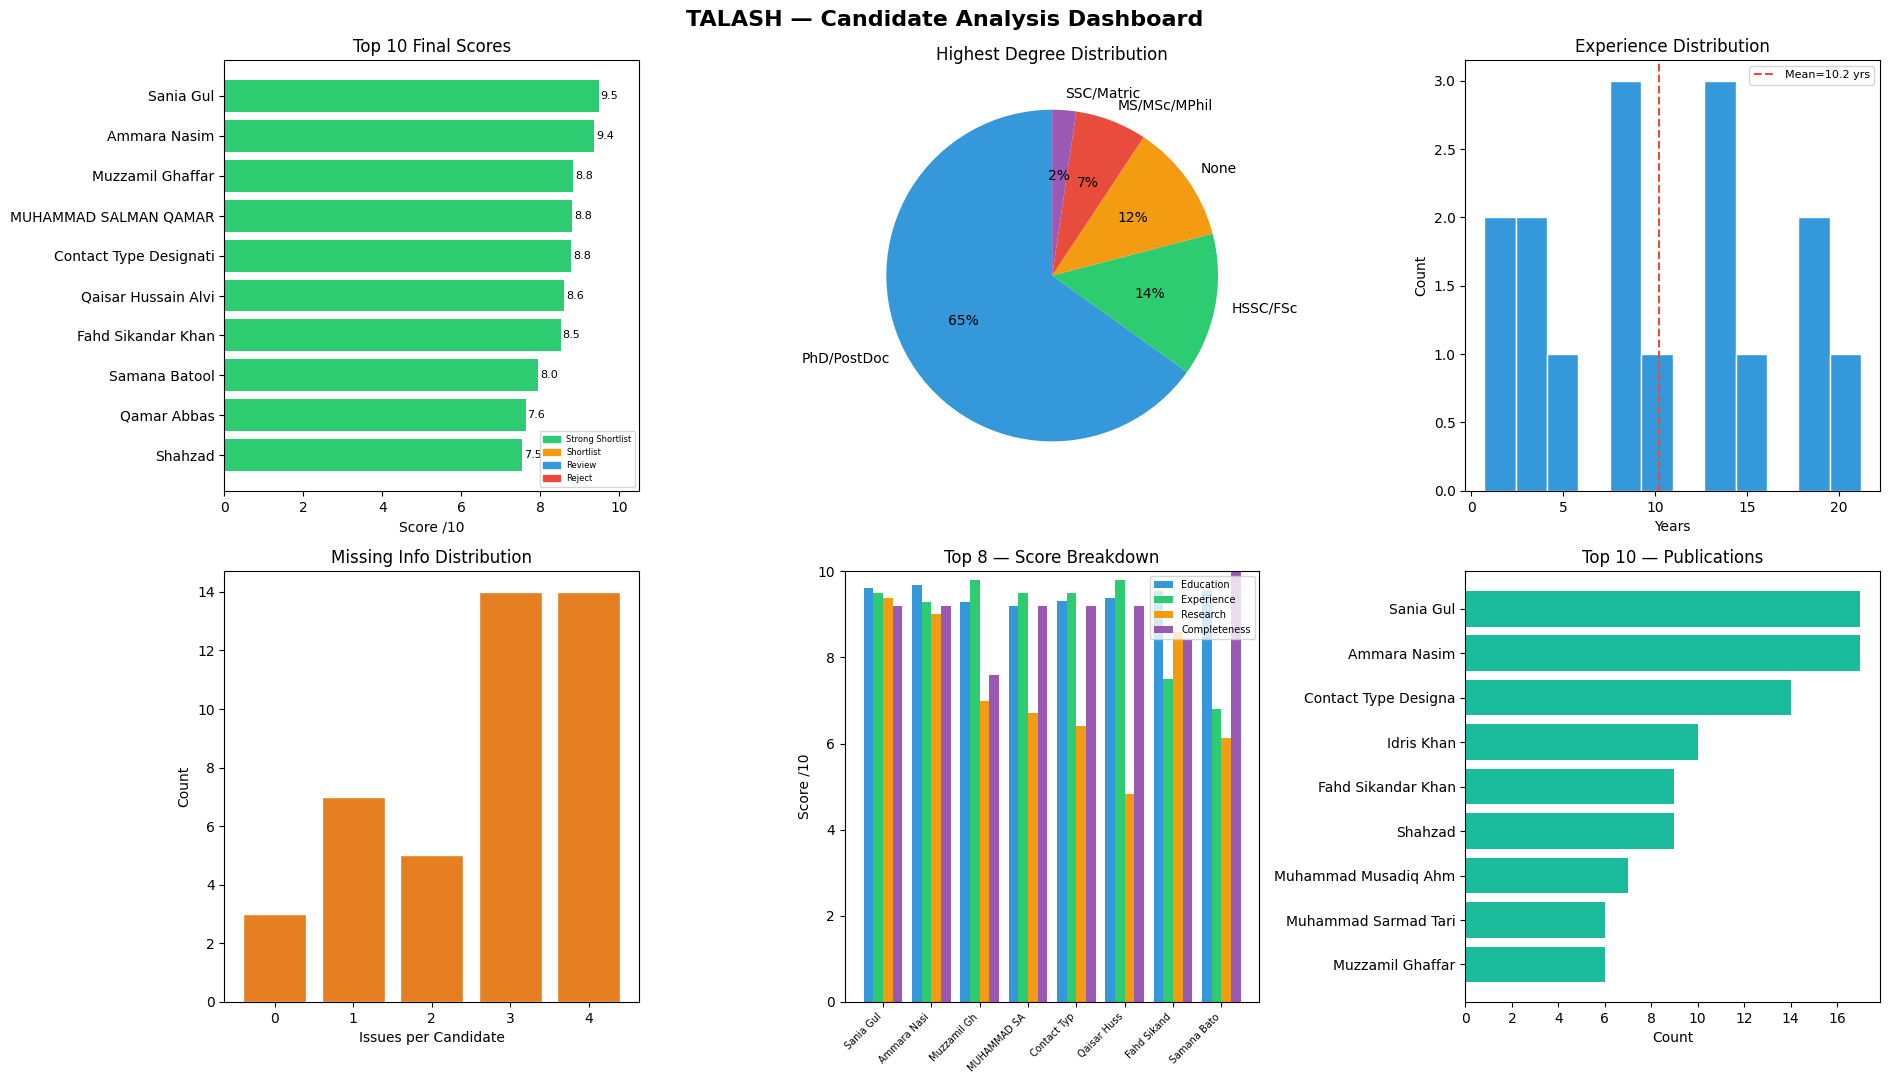

In [12]:
%matplotlib inline

def create_dashboard(ranking_df, edu_df, exp_df, res_df, mis_df):
    if ranking_df.empty:
        print('No data to visualise.')
        return
    fig, axes = plt.subplots(2, 3, figsize=(19, 11))
    fig.suptitle('TALASH — Candidate Analysis Dashboard', fontsize=16, fontweight='bold')
    REC_COLORS = {'Strong Shortlist':'#2ecc71','Shortlist':'#f39c12',
                  'Review':'#3498db','Reject':'#e74c3c'}
    ax  = axes[0,0]
    top = ranking_df.head(10).copy()
    bars = ax.barh(top['Name'].str[:22], top['Final Score /10'],
                   color=[REC_COLORS.get(r,'#95a5a6') for r in top['Recommendation']])
    for b,v in zip(bars, top['Final Score /10']):
        ax.text(b.get_width()+0.05, b.get_y()+b.get_height()/2, f'{v:.1f}', va='center', fontsize=8)
    ax.set_xlim(0,10.5); ax.set_xlabel('Score /10'); ax.set_title('Top 10 Final Scores'); ax.invert_yaxis()
    ax.legend(handles=[mpatches.Patch(color=v,label=k) for k,v in REC_COLORS.items()], fontsize=6, loc='lower right')
    ax = axes[0,1]
    if not edu_df.empty:
        dc = edu_df['Highest Degree'].value_counts()
        ax.pie(dc.values, labels=dc.index, autopct='%1.0f%%',
               colors=['#3498db','#2ecc71','#f39c12','#e74c3c','#9b59b6','#95a5a6'], startangle=90)
        ax.set_title('Highest Degree Distribution')
    ax = axes[0,2]
    if not exp_df.empty:
        ev = exp_df['Total Exp (Years)'].dropna(); ev = ev[ev>0]
        if not ev.empty:
            ax.hist(ev, bins=min(12,len(ev)), color='#3498db', edgecolor='white')
            ax.axvline(ev.mean(), color='#e74c3c', linestyle='--', label=f'Mean={ev.mean():.1f} yrs')
            ax.set_xlabel('Years'); ax.set_ylabel('Count'); ax.set_title('Experience Distribution'); ax.legend(fontsize=8)
    ax = axes[1,0]
    if not mis_df.empty:
        mc = mis_df['Issues Found'].value_counts().sort_index()
        ax.bar(mc.index.astype(str), mc.values, color='#e67e22', edgecolor='white')
        ax.set_xlabel('Issues per Candidate'); ax.set_ylabel('Count'); ax.set_title('Missing Info Distribution')
    ax = axes[1,1]
    if not ranking_df.empty:
        t8 = ranking_df.head(8); x = np.arange(len(t8)); w = 0.2
        ax.bar(x-w*1.5, t8['Edu Score /10'],      width=w, label='Education',    color='#3498db')
        ax.bar(x-w*0.5, t8['Exp Score /10'],      width=w, label='Experience',   color='#2ecc71')
        ax.bar(x+w*0.5, t8['Research Score /10'], width=w, label='Research',     color='#f39c12')
        ax.bar(x+w*1.5, t8['Completeness /10'],   width=w, label='Completeness', color='#9b59b6')
        ax.set_xticks(x); ax.set_xticklabels([n[:11] for n in t8['Name']], rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0,10); ax.set_ylabel('Score /10'); ax.set_title('Top 8 — Score Breakdown'); ax.legend(fontsize=7)
    ax = axes[1,2]
    if not res_df.empty:
        tp = res_df.nlargest(10,'Total Publications')
        ax.barh(tp['Name'].str[:20], tp['Total Publications'], color='#1abc9c')
        ax.set_xlabel('Count'); ax.set_title('Top 10 — Publications'); ax.invert_yaxis()
    plt.tight_layout()
    path = 'outputs/talash_dashboard.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Dashboard saved → {path}')
    plt.show()

if extracted_data:
    create_dashboard(ranking_df, education_analysis_df, experience_analysis_df, research_df, missing_info_df)
else:
    print('Run Cell 5 first.')

## **Save All Outputs**

In [13]:
# Save All Outputs

_CTRL_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f]')

def clean_for_excel(df):
    return df.apply(lambda col: col.apply(
        lambda x: _CTRL_RE.sub('', x) if isinstance(x, str) else x))

def safe_df(lst, cols=None):
    return pd.DataFrame(lst) if lst else pd.DataFrame(columns=cols or ['No Data'])

def save_all(extracted_data, ranking_df, edu_df, exp_df, res_df, mis_df,
             summary_df, emails_df, split_df):
    print('[Saving outputs...]')
    sheets = {
        'Personal Info':       safe_df(extracted_data['personal']),
        'Education':           safe_df(extracted_data['education']),
        'Prof Qualifications': safe_df(extracted_data['prof_qual']),
        'Experience':          safe_df(extracted_data['experience']),
        'Publications':        safe_df(extracted_data['publications']),
        'Awards':              safe_df(extracted_data['awards']),
        'Patents':             safe_df(extracted_data['patents']),
        'References':          safe_df(extracted_data['references']),
        'Skills':              safe_df(extracted_data['skills']),
        'Education Analysis':  edu_df     if not edu_df.empty     else pd.DataFrame(),
        'Experience Analysis': exp_df     if not exp_df.empty     else pd.DataFrame(),
        'Research Analysis':   res_df     if not res_df.empty     else pd.DataFrame(),
        'Ranking':             ranking_df if not ranking_df.empty else pd.DataFrame(),
        'Summaries':           summary_df if not summary_df.empty else pd.DataFrame(),
        'Missing Info':        mis_df     if not mis_df.empty     else pd.DataFrame(),
        'PDF Split Summary':   split_df   if not split_df.empty   else pd.DataFrame(),
    }
    try:
        with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as w:
            for sname, df in sheets.items():
                target = df if not df.empty else pd.DataFrame(columns=['No Data'])
                clean_for_excel(target).to_excel(w, sheet_name=sname[:31], index=False)
        print(f'  Excel  → {OUTPUT_EXCEL}  ({len(sheets)} sheets)')
    except Exception as e:
        print(f'  [ERROR] Excel: {e}')
    try:
        jdata = dict(extracted_data)
        if not ranking_df.empty: jdata['ranking'] = ranking_df.to_dict(orient='records')
        with open(OUTPUT_JSON,'w',encoding='utf-8') as f:
            json.dump(jdata, f, indent=4, ensure_ascii=False, default=str)
        print(f'  JSON   → {OUTPUT_JSON}')
    except Exception as e:
        print(f'  [ERROR] JSON: {e}')
    try:
        dp = pd.DataFrame(extracted_data['personal'])
        if not dp.empty:
            clean_for_excel(dp).to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
            print(f'  CSV    → {OUTPUT_CSV}')
    except Exception as e:
        print(f'  [ERROR] CSV: {e}')
    try:
        if not emails_df.empty:
            epath = 'outputs/draft_emails.txt'
            with open(epath,'w',encoding='utf-8') as f:
                for _, row in emails_df.iterrows():
                    f.write('='*60+'\n')
                    f.write(f'TO     : {row["Name"]}\n')
                    f.write(f'TYPE   : {row["Email Type"]}\n')
                    f.write(f'SUBJECT: {row["Subject"]}\n\n')
                    f.write(row['Email Body']+'\n\n')
            print(f'  Emails → {epath}')
    except Exception as e:
        print(f'  [ERROR] Emails: {e}')
    print('\nAll outputs saved.')

if extracted_data:
    save_all(extracted_data, ranking_df, education_analysis_df,
             experience_analysis_df, research_df, missing_info_df,
             summary_df, emails_df, pdf_split_summary_df)
else:
    print('Run Cell 5 first.')

[Saving outputs...]
  Excel  → outputs/talash_m2_output.xlsx  (16 sheets)
  JSON   → outputs/talash_m2_output.json
  CSV    → outputs/talash_m2_personal.csv
  Emails → outputs/draft_emails.txt

All outputs saved.


## **Interactive Candidate Explorer**

In [14]:
# Interactive Candidate Explorer

def show_profile(cid):
    print('='*58)
    p = pd.DataFrame(extracted_data['personal'])
    r = p[p['candidate_id']==cid]
    if not r.empty:
        row = r.iloc[0]
        print(f'  #{cid}  {row["Name"]}')
        print(f'  DOB        : {row["Date of Birth"]}')
        print(f'  Email      : {row["Email"]}')
        print(f'  Employment : {str(row["Present Employment"])[:65]}')
        print(f'  Source PDF : {row["Source File"]}  (Multi-CV: {row["extracted_from_multi_cv"]})')
    print('-'*58)
    def show(sname, df, cols):
        if df is not None and not df.empty:
            sub = df[df['candidate_id']==cid][cols]
            if not sub.empty:
                print(f'  {sname}:')
                print(sub.to_string(index=False))
                print()
    if extracted_data.get('education'):
        show('EDUCATION', pd.DataFrame(extracted_data['education']), ['Degree/Details','Year','Grade/CGPA'])
    if extracted_data.get('experience'):
        show('EXPERIENCE', pd.DataFrame(extracted_data['experience']), ['Position & Org','Duration'])
    if not education_analysis_df.empty:
        er = education_analysis_df[education_analysis_df['candidate_id']==cid]
        if not er.empty: print(f'  EDU SCORE  : {er.iloc[0]["Edu Score /10"]} /10  ({er.iloc[0]["Highest Degree"]})')
    if not experience_analysis_df.empty:
        xr = experience_analysis_df[experience_analysis_df['candidate_id']==cid]
        if not xr.empty: print(f'  EXP SCORE  : {xr.iloc[0]["Exp Score /10"]} /10  ({xr.iloc[0]["Total Exp (Years)"]} yrs)')
    if not research_df.empty:
        rr = research_df[research_df['candidate_id']==cid]
        if not rr.empty: print(f'  RES SCORE  : {rr.iloc[0]["Research Score /10"]} /10  ({rr.iloc[0]["Total Publications"]} pubs)')
    if not ranking_df.empty:
        rkr = ranking_df[ranking_df['candidate_id']==cid]
        if not rkr.empty:
            print(f'  FINAL      : {rkr.iloc[0]["Final Score /10"]} /10  Rank #{rkr.iloc[0]["Rank"]}  [{rkr.iloc[0]["Recommendation"]}]')
    if not summary_df.empty:
        sr = summary_df[summary_df['candidate_id']==cid]
        if not sr.empty:
            print(f'  SUITABILITY: {sr.iloc[0]["Suitability"]}  (Source: {sr.iloc[0]["Source"]})')
            print(f'  STRENGTHS  : {str(sr.iloc[0]["Strengths"])[:120]}')
    print('='*58)

try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display, clear_output
    if extracted_data:
        pdf  = pd.DataFrame(extracted_data['personal'])
        opts = [(f'#{r["candidate_id"]} — {r["Name"][:28]}', r['candidate_id']) for _, r in pdf.iterrows()]
        dd   = widgets.Dropdown(options=opts, description='Candidate:', layout=widgets.Layout(width='55%'))
        out  = widgets.Output()
        def on_ch(ch):
            if ch['type']=='change' and ch['name']=='value':
                with out:
                    clear_output()
                    show_profile(ch['new'])
        dd.observe(on_ch)
        print('Select a candidate from the dropdown:')
        ipy_display(dd, out)
except ImportError:
    print('ipywidgets not available — showing first 5 profiles:')
    if extracted_data:
        pdf = pd.DataFrame(extracted_data['personal'])
        for cid in pdf['candidate_id'].head(5).tolist():
            show_profile(cid)

Select a candidate from the dropdown:


Dropdown(description='Candidate:', layout=Layout(width='55%'), options=(('#1 — MUHAMMAD SALMAN QAMAR', 1), ('#…

Output()

In [15]:
# Final Report

def final_report():
    print('\n' + '='*58)
    print('  TALASH MILESTONE 2 — FINAL REPORT (v2)')
    print('='*58)
    if not extracted_data:
        print('No data available. Run Cell 5 first.')
        return
    print(f'\n  EXTRACTION')
    print(f'    Candidates  : {len(extracted_data["personal"])}')
    print(f'    Education   : {len(extracted_data["education"])} rows')
    print(f'    Experience  : {len(extracted_data["experience"])} rows')
    print(f'    Publications: {len(extracted_data["publications"])} rows')
    print(f'    Awards      : {len(extracted_data["awards"])} rows')
    print(f'\n  LLM MODE    : {"REAL API" if USE_LLM and API_KEY else "Rule-based (set USE_LLM=True)"}')
    if not summary_df.empty:
        src_counts = summary_df['Source'].value_counts().to_dict()
        print(f'  SUMMARIES   : {src_counts}')
    if not ranking_df.empty:
        print(f'\n  RANKING')
        for lbl, cnt in ranking_df['Recommendation'].value_counts().items():
            print(f'    {lbl:<22}: {cnt}')
        print(f'\n  TOP 5 CANDIDATES')
        for _, row in ranking_df.head(5).iterrows():
            print(f'    #{row["Rank"]}  {row["Name"][:35]:<35}  {row["Final Score /10"]:.2f}  [{row["Recommendation"]}]')
    if pdf_split_summary_df is not None and not pdf_split_summary_df.empty:
        print(f'\n  PDF PROCESSING')
        for _, row in pdf_split_summary_df.iterrows():
            print(f'    {str(row["pdf_name"])[:38]:<38} → {row["split_status"]} | {row["detected_candidates"]} candidates')
    print(f'\n  OUTPUT FILES')
    for f in [OUTPUT_EXCEL, OUTPUT_JSON, OUTPUT_CSV,
               'outputs/draft_emails.txt', 'outputs/talash_dashboard.png']:
        exists = '✓' if os.path.exists(f) else '✗'
        print(f'    {exists} {f}')
    print('\n' + '='*58)
    print('  PIPELINE COMPLETE')
    print('='*58)

final_report()


  TALASH MILESTONE 2 — FINAL REPORT (v2)

  EXTRACTION
    Candidates  : 43
    Education   : 167 rows
    Experience  : 68 rows
    Publications: 130 rows
    Awards      : 23 rows

  LLM MODE    : REAL API
  SUMMARIES   : {'LLM': 43}

  RANKING
    Review                : 20
    Strong Shortlist      : 11
    Reject                : 8
    Shortlist             : 4

  TOP 5 CANDIDATES
    #1  Sania Gul                            9.48  [Strong Shortlist]
    #2  Ammara Nasim                         9.36  [Strong Shortlist]
    #3  Muzzamil Ghaffar                     8.84  [Strong Shortlist]
    #4  MUHAMMAD SALMAN QAMAR                8.80  [Strong Shortlist]
    #5  Contact Type Designation AddressPho  8.78  [Strong Shortlist]

  PDF PROCESSING
    Handler (8).pdf                        → MULTI | 68 candidates

  OUTPUT FILES
    ✓ outputs/talash_m2_output.xlsx
    ✓ outputs/talash_m2_output.json
    ✓ outputs/talash_m2_personal.csv
    ✓ outputs/draft_emails.txt
    ✓ outputs/talas